# Cafe Sales Analysis

## Analysis Objective:

- This analysis documents the complete data analysis workflow for a café sales dataset, from data preparation and cleaning to exploratory analysis and visualization. 
- The goal is to transform raw transactional data into meaningful insights that reveal customer behavior, sales patterns, and opportunities for business improvement.

In [ ]:
# Original
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


## Data Loading

In [85]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (4)\dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


## Data Preview

In [86]:
print("Dataset Shape:")
print(df.shape)

display(df.head())

print("\nColumn Names:")
for col in df.columns:
    print(f"{col}")

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nPercentage Missing:")
display((df.isnull().mean() * 100).round(2))

Dataset Shape:
(10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11



Column Names:
Transaction ID
Item
Quantity
Price Per Unit
Total Spent
Payment Method
Location
Transaction Date

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB

Summary Statistics:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159



Missing Values:


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


Percentage Missing:


Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

## Data cleaning

In [87]:
# standardizing categorical columns
categorical_columns = [
    "Item",
    "Location",
    "Payment Method"
]

for col in categorical_columns:
    df[col] =(
        df[col]
        .str.strip()
        .str.title()
        .replace({
            "Unknown": np.nan,
            "Error" : np.nan,
            "": np.nan
        })
    )

df_clean = df.dropna(subset= categorical_columns)
df = df_clean

In [88]:
# standardizing numerical columns

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors = "coerce")

df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["Day"] =  df["Transaction Date"].dt.day
df["Day_Name"] = df["Transaction Date"].dt.day_name()


# Total  spent
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors= "coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors = "coerce")

# Quantity
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]


In [89]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Day_Name
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,8.0,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023.0,5.0,16.0,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023.0,7.0,19.0,Wednesday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023.0,6.0,11.0,Sunday
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023.0,11.0,7.0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-Store,2023-07-20,2023.0,7.0,20.0,Thursday
9984,TXN_3142496,Smoothie,3.0,4.0,12.0,Cash,Takeaway,2023-07-27,2023.0,7.0,27.0,Thursday
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-Store,2023-12-14,2023.0,12.0,14.0,Thursday
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24,2023.0,2.0,24.0,Friday


In [90]:
# Cleaning validation
print("Remaining Missing Values")
display(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
display(df.dtypes)

Remaining Missing Values


Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    168
Year                168
Month               168
Day                 168
Day_Name            168
dtype: int64


Duplicate Rows
0

Data Types


Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Year                       float64
Month                      float64
Day                        float64
Day_Name                       str
dtype: object

##### Cleaning Validation
- Numerical columns were succesfully converted to their appropriate data types.
- Missing values in Quantity, Price Per Unit, and Total Spent were resolved.
- Categorical columns were standardized by removing whitespaces and replacing invalid placeholders with 'Nan'.
- Transaction Date retained 460 missing values (4.6%) because the records contained invalid placeholders,("#####"), that cannot be converted to valid dates. Therefore the column was retained since over 95% of the observations have valid dates, making it suitable for time-based analyses.

## Exploratory Data Analysis

### A. Univariate 

In [91]:
df[["Quantity", "Price Per Unit", "Total Spent"]].describe()

,Quantity,Price Per Unit,Total Spent
count,3748.000000,3748.000000,3748.000000
mean,3.032017,2.954776,8.968783
std,1.388327,1.263051,5.881329
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [92]:
df.to_csv("dirty_cafe_sales_clean.csv",index = False)

### B. Bivariate Analysis 
- Revenue per Item
- Revenue by Location
- Revenue by Payment Method
- Sales per Day


#### Figure 1 .Revenue by Item

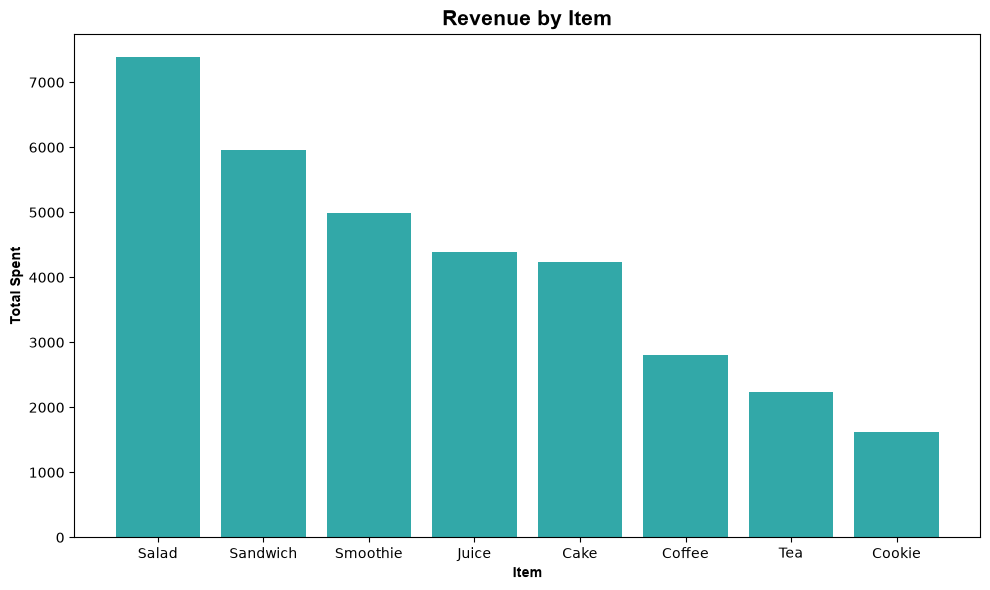

In [105]:
df_grouped = df.groupby("Item")["Total Spent"].sum().reset_index().sort_values(by ="Total Spent", ascending= False)

plt.figure(figsize= (10,6))
plt.bar( "Item", "Total Spent", data = df_grouped, color = "#32a8a8")


plt.title("Revenue by Item",size = 15, family ="Arial", fontweight= "bold")
plt.xlabel("Item", size = 10, family = "Arial", fontweight ="bold")
plt.ylabel("Total Spent",size = 10, family = "Arial", fontweight ="bold")

plt.tight_layout()
plt.show()


****Observation**
- This bar chart displays total revenue generated by each item in the café menu.
- The leading products in sales were Salad and Sandwich with cookies making the least sales.
- The analysis reveals which products are the strongest revenue generators helping identify products that drive business profitability. 
- Items are ranked from highest to lowest revenue, making it easy to identify top performers and compare relative sales performance across the menu.


**Business Insight:**
- Focus marketing and inventory efforts on top-revenue items to maximize profitability.

#### Figure 2. Revenue by Location

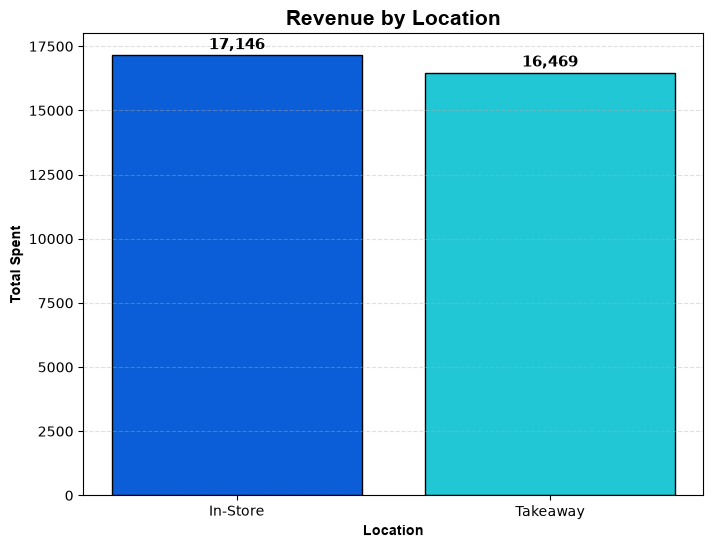

In [94]:
df_grouped = df.groupby("Location")["Total Spent"].sum().reset_index().sort_values(by= "Total Spent", ascending =False)

plt.figure(figsize= (8,6))

colors = [ "#0B5ED7", "#22C7D5"]

bars = plt.bar(
    df_grouped["Location"],
    df_grouped["Total Spent"],
    color = colors,
    edgecolor= "black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,          
        f"{bar.get_height():,.0f}",     
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


plt.title("Revenue by Location",size = 15, family ="Arial", fontweight= "bold")
plt.xlabel("Location", size = 10, family = "Arial", fontweight ="bold")
plt.ylabel("Total Spent",size = 10, family = "Arial", fontweight ="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

**Revenue by Location:**

- This comparison shows revenue generated across different sales channels (In-store vs. Take-away). 
- The data reveals In-Store location type contributes more to overall sales than Take-way by a small margin.
- This indicates the relative importance of each channel in the business model. 
- Both channels are visualized with distinct colors and labeled with exact revenue figures for easy comparison.

**Business Insight:** 
- Both locations contribute significantly to revenue; ensure consistent operations and staffing across all channels.

#### Figure 3. Total Revenue by Payment Method

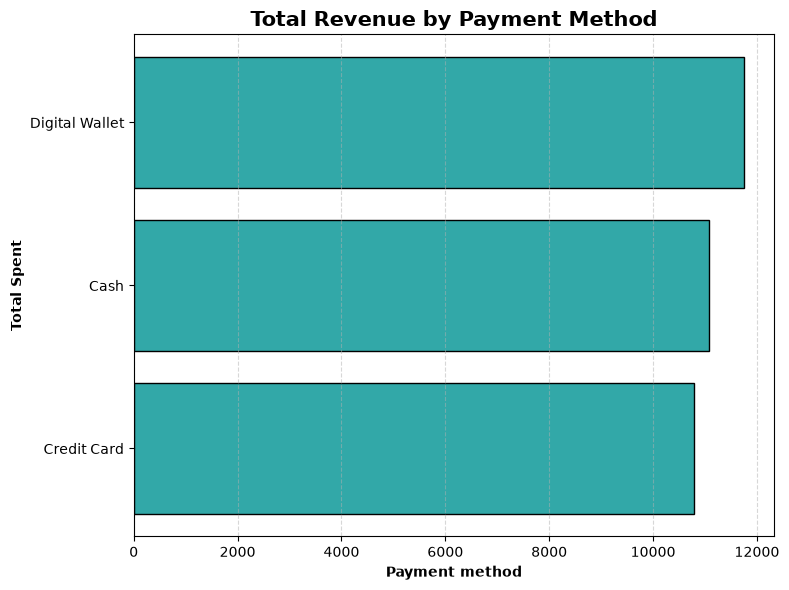

In [104]:
df_grouped =(df.groupby("Payment Method")["Total Spent"]
             .sum()
             .sort_values(ascending= True))

plt.figure(figsize= (8,6))
plt.barh(
    df_grouped.index,
    df_grouped.values,
    color = "#32a8a8",
    edgecolor= "black"
)


plt.title("Total Revenue by Payment Method", fontsize = 15, fontweight = "bold")
plt.xlabel("Payment method", fontweight = "bold")
plt.ylabel("Total Spent", fontweight = "bold")

plt.grid(axis= "x", linestyle= "--", alpha = 0.5)
plt.tight_layout()
plt.show()


**Revenue by Payment Method:**

- This horizontal bar chart showing the distribution of revenue across different payment methods (Cash, Card,and Digital Wallet).
- Digital wallets are the top payment method, though cash and credit cards trail by only a small margin.
- The horizontal layout makes it easy to read payment method labels and compare relative revenue contributions.

**Business Insight:**
- While keeping all preferred payment methods readily available to preserve customer choice, consider implementing incentives that promote the most operationally efficient payment channels.

#### Figure 4. Sales per Day of the Week

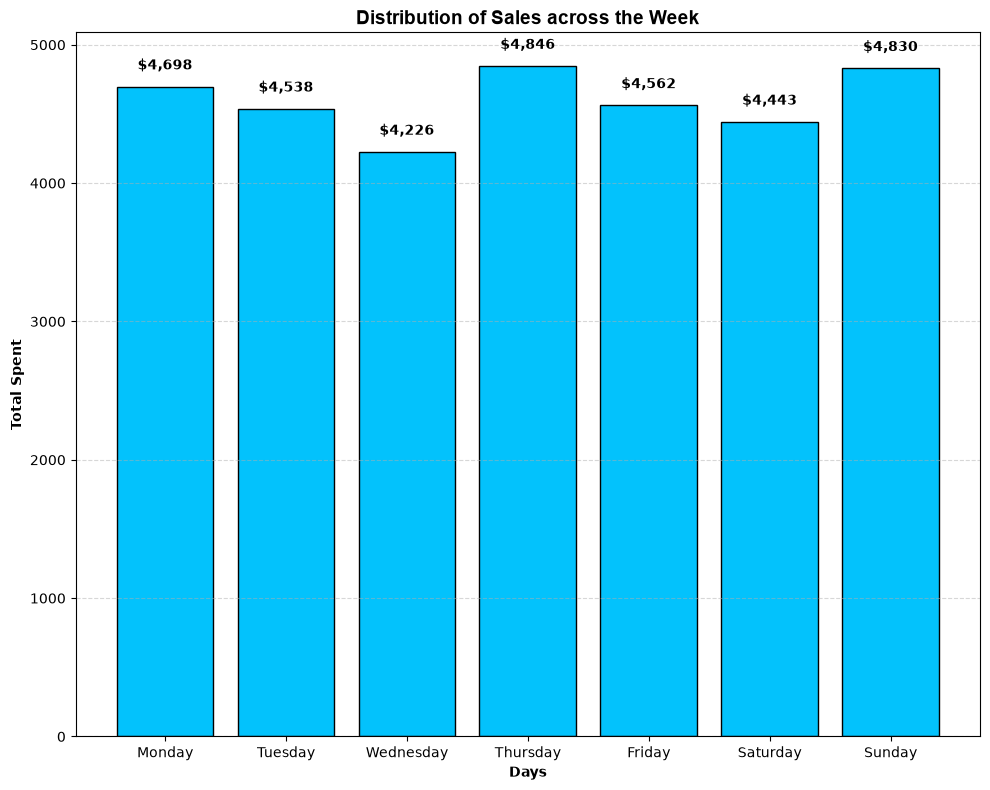

In [108]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_grouped = df.groupby("Day_Name")["Total Spent"].sum().reindex(days_order).reset_index()


plt.figure(figsize=(10,8))
bars = plt.bar(
    "Day_Name", 
    "Total Spent",
    data= df_grouped, 
    color="#03c2fc", 
    edgecolor ="black")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 100,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


plt.title("Distribution of Sales across the Week",size =14, family= "Arial", fontweight= "bold")
plt.xlabel("Days", fontweight = "bold")
plt.ylabel("Total Spent",fontweight = "bold")
plt.grid(axis="y", linestyle ="--", alpha = 0.5)

plt.tight_layout()
plt.show()

**Sales per Day of Week:**

- The bar chart illustrates sales patterns across the seven days of the week, revealing daily seasonal trends in customer traffic and spending. 
- Identifying peak and low-performing days enables better staffing decisions, inventory management, and promotional planning. Clear day-by-day comparisons help recognize weekly patterns in customer behavior.

**Business Insight:** Allocate more staff and inventory to peak days and consider targeted promotions on slower days to balance demand.

### C. Multivariate Analysis
- Revenue by Payment Method and Location
- Payment Method Preference by Item
- Item Sales - Instore vs Take-away
- Revenue Items by Day of the week

#### Figure 5. Revenue Distribution by Payment Method and Location

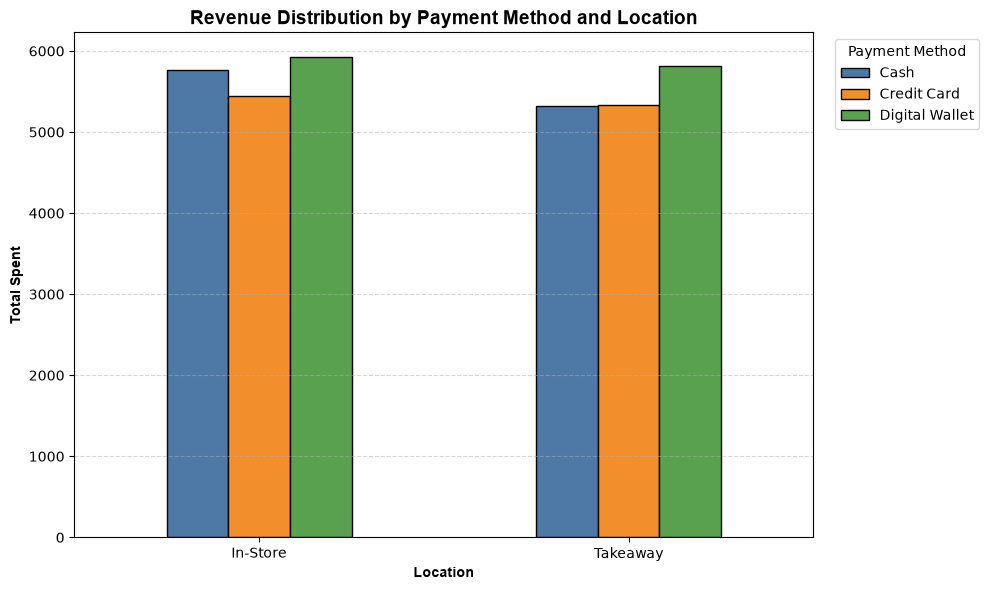

In [109]:
pivot = df.pivot_table(
    values = "Total Spent",
    index= "Location",
    columns = "Payment Method",
    aggfunc= "sum",
)

colors = [ "#4E79A7", "#F28E2B", "#59A14F"]

pivot.plot(
    kind= "bar",
    figsize = (10,6),
    edgecolor = "black",
    color = colors
)

plt.title("Revenue Distribution by Payment Method and Location", size= 14,family ="Arial", fontweight="bold")
plt.xlabel("Location",family ="Arial", fontweight ="bold")
plt.ylabel("Total Spent",family ="Arial", fontweight="bold")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle= "--", alpha= 0.5)

plt.legend(
    title ="Payment Method",
    bbox_to_anchor = (1.02,1),
    loc = "best"
    )

plt.tight_layout()
plt.show()

**Revenue by Payment Method and Location:**

- This grouped bar chart reveals the interaction between location and payment method, showing which payment options are preferred at each location. 
- This insight is crucial for understanding customer behavior patterns and payment infrastructure requirements at different touchpoints. 
- The side-by-side comparison makes it easy to spot location-specific payment preferences.

**Business Insight:** Tailor payment options to location-specific customer preferences and ensure all popular payment methods are available at peak-revenue locations.

#### Figure 6. Payment Method Preference by Item

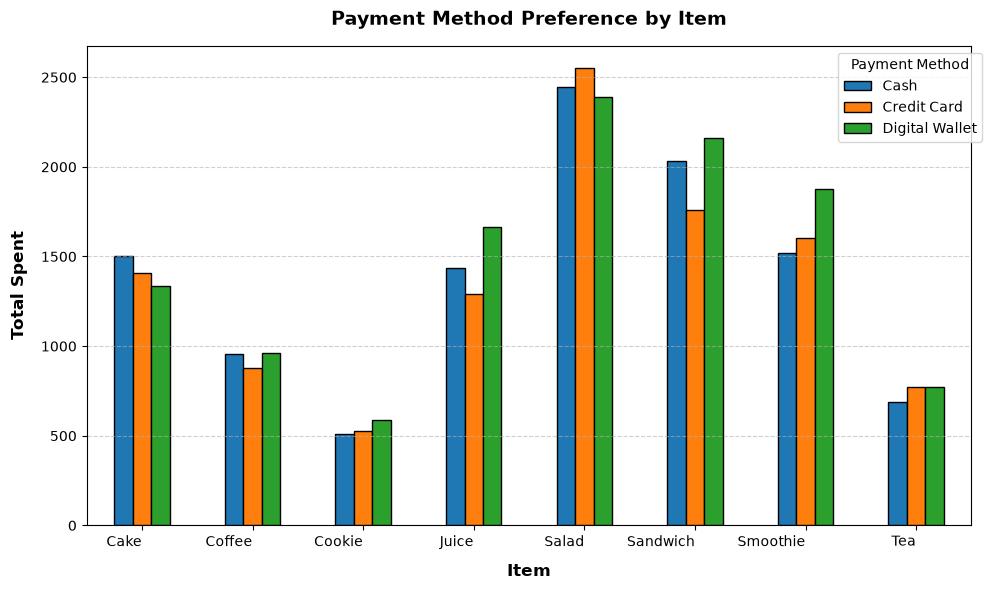

In [98]:
pivot = df.pivot_table(
    values= "Total Spent",
    index = "Item",
    columns= "Payment Method",
    aggfunc= "sum"
)

ax = pivot.plot(
     kind= "bar",
     figsize =(10,6),
     edgecolor = "black"
)

plt.title("Payment Method Preference by Item", size =14, fontweight ="bold", pad =15)
plt.xlabel("Item", fontsize = 12,  fontweight ="bold", labelpad= 10)
plt.ylabel("Total Spent", fontsize= 12, fontweight ="bold", labelpad = 10)
plt.xticks(rotation = 0, ha="right")
plt.grid(axis="y", linestyle = "--", alpha = 0.6)

plt.legend(
    title ="Payment Method",
    bbox_to_anchor = (1.02,1),
    loc = "best"
    )
plt.tight_layout()
plt.show()

**Payment Method Preference by Item:**

- This visualization shows how payment method preferences vary across different menu items. 
- Some items might be predominantly purchased using specific payment methods, reflecting customer preferences or purchasing contexts (e.g., quick grab-and-go items paid by card). 
- Understanding these patterns helps optimize the payment experience for different product categories.

**Business Insight:** Analyze item-specific payment preferences to understand customer purchasing behavior.

#### Figure 7. Item Sales - In-Store vs. Take-Away

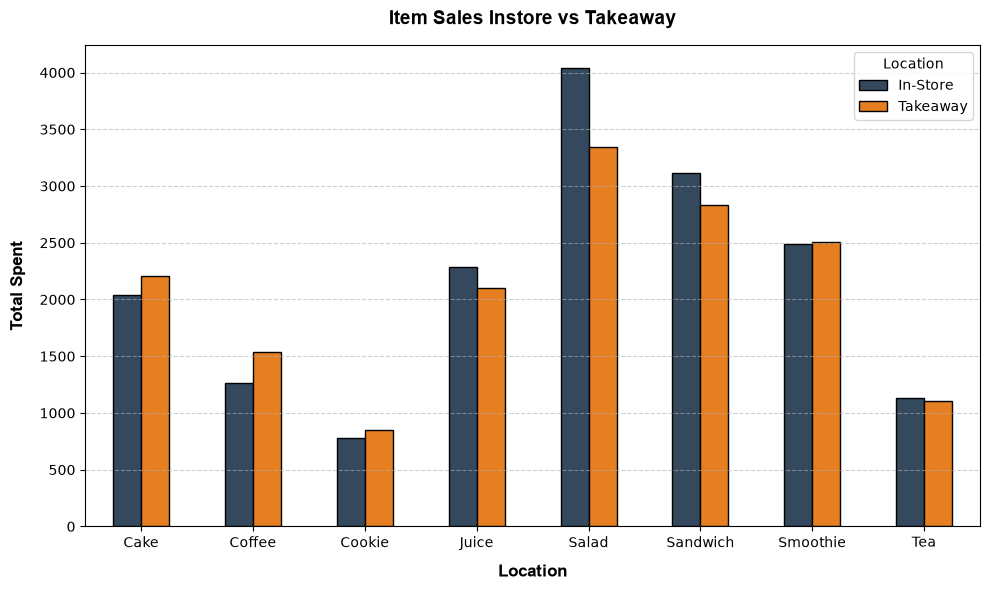

In [99]:
pivot = df.pivot_table(
    values= "Total Spent",
    index = "Item",
    columns= "Location",
    aggfunc= "sum"
)

colors =["#34495e", "#e67e22"]

pivot.plot(
    kind = "bar",
    figsize = (10,6),
    edgecolor ="black",
    color = colors
)

plt.title("Item Sales Instore vs Takeaway", size = 14, family = "Arial", fontweight ="bold", pad = 15)
plt.xlabel("Location",size = 12, family= "Arial", fontweight = "bold", labelpad = 10 )
plt.ylabel("Total Spent",size = 12, family= "Arial", fontweight = "bold", labelpad = 10 )
plt.xticks(rotation = 0)
plt.grid(axis = "y", linestyle ="--", alpha = 0.6)

plt.tight_layout()
plt.show()

**Item Sales by Location (In-Store vs. Take-Away):**

- This comparative analysis reveals which menu items perform better in in-store versus take-away contexts. 
- Some items may be preferred for consumption on-premises while others are better suited for takeaway. 
- This insight helps optimize product availability across channels and tailor marketing messages to each location type.

**Business Insight:** 
- Ensure high-performing items are adequately stocked for their preferred sales channel and consider channel-specific menu variations.

#### Figure 8. Revenue Heatmap - Items by Day of Week


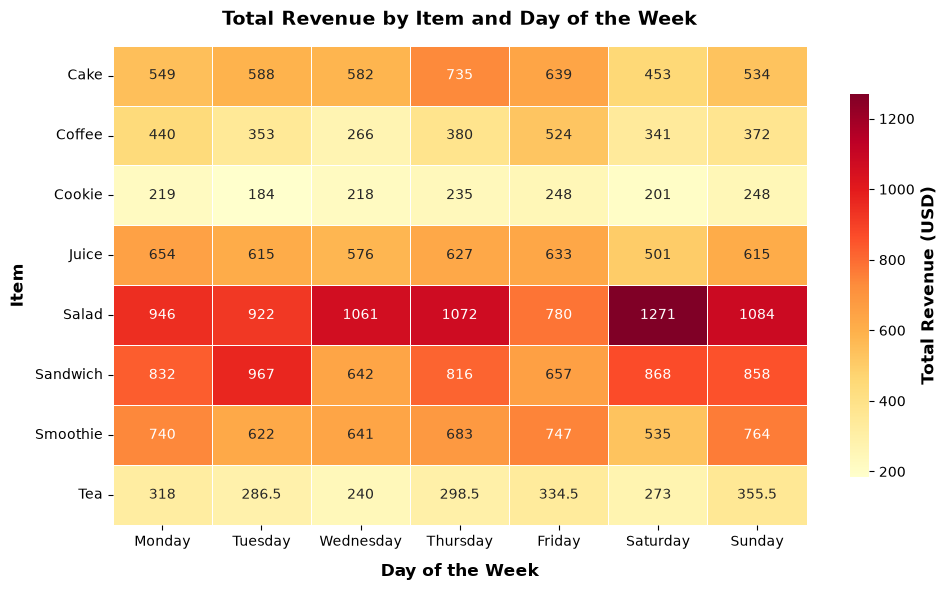

In [100]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["Day_Name"] = pd.Categorical(
    df["Day_Name"],
    categories=day_order,
    ordered=True)


pivot_days = df.pivot_table(
    values="Total Spent", 
    index="Day_Name", 
    columns="Item", 
    aggfunc="sum")

plt.figure(figsize= (10,6))

ax= sns.heatmap(
    pivot_days.T,  
    cmap="YlOrRd",
    annot=True,
    fmt="g",
    linewidths=0.5,
    cbar_kws={
        "label": "Total Spent",
        "shrink": 0.8}
)
cbar = ax.collections[0].colorbar

cbar.set_label(
    "Total Revenue (USD)",
    fontsize=12,
    fontweight="bold"
)

plt.title("Total Revenue by Item and Day of the Week", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of the Week", fontsize=12,fontweight ="bold", labelpad=10)
plt.ylabel("Item", fontsize=12, fontweight ="bold", labelpad=6)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



**Revenue Heatmap by Item and Day:**

- This heatmap provides a comprehensive view of how different menu items perform across each day of the week. 
- The color intensity indicates revenue levels, with darker colors representing higher revenues. 
- This visualization makes it easy to identify both best-performing products and optimal selling days, as well as spot any day-item combinations that underperform. 

**Business Insight:** Align production schedules and staff shifts with the predicted revenue patterns for each day-item combination to optimize resource utilization.

## Conclusions

### Key Findings

1. **Revenue Drivers**: 
-The analysis identified menu items(salad, sandwich) and time periods(Thursday, Sunday and Monday) generate the highest revenue.
- This inturn allows targeted focus on high-performing products.

2. **Location**:
- Both in-store and take-away locations contribute nearly equally to total revenue with In-Store on the lead.

3. **Payment Diversity**: 
- The payment methods, digital wallet , cash and credit card are utilized across the customer base, with specific preferences varying by location and item type.
- Digital Wallet is the most common payment method.

4. **Item-Location Interaction**: 
- Different menu items show varying performance across in-store and take-away channels.
- The most popular products across the locations are salad and sandwich.

5. **Item Preferences**:
- Item popularity varies by day of the week, revealing seasonal demand patterns that can be leveraged for menu planning and promotions.
- Salad makes the most sales across the week apart from on Tuesday where Sandwich makes the most  sales.



### Business Recommendations

#### 1. **Inventory & Supply Chain Optimization**
- Stock high-performing items(Salad, Sandwich,, Smoothie and juice) at higher quantities, especially during peak days identified in the day-of-week analysis
- Create day-specific inventory plans based on the heatmap showing item popularity by day
- Negotiate bulk purchasing agreements for consistently high-revenue items

#### 2. **Staffing & Operations**
- Allocate additional staff to peak revenue days
- Cross-train staff for both in-store and take-away operations given the equal revenue contribution from both channels
- Implement shift scheduling that aligns with daily demand patterns to reduce labor costs while maintaining service quality

#### 3. **Payment Infrastructure**
- Ensure all identified payment methods are reliably available at every location
- Invest in faster checkout systems for high-volume payment methods at peak times
- Consider offering incentives for digital payments to reduce cash handling costs and improve transaction speed

#### 4. **Marketing & Promotions**
- Launch targeted promotions for high-revenue items on their peak days to maximize sales
- Create strategic "off-peak" promotions on slower days (e.g., Monday or Tuesday discounts) to smooth demand and increase overall revenue
- Develop location-specific marketing strategies that emphasize items performing better in each channel (in-store vs. take-away)

#### 5. **Menu Development**
- Review and potentially revise menu items with consistently low performance across all days and channels
- Consider limited-time offerings featuring high-revenue items during their peak days
- Test complementary product bundles based on item-specific payment and location preferences

#### 6. **Channel Strategy**
- Given the nearly equal contribution from both locations, ensure consistent brand experience and service quality across in-store and take-away operations
- Develop location-specific packaging and presentation standards that enhance the respective customer experience
- Use location-specific insights to tailor the product mix and pricing strategy for each channel

#### 7. **Data-Driven Forecasting**
- Implement the daily and item-level patterns identified in this analysis into a forecasting model for better capacity and resource planning
- Create alerts for anomalies that deviate significantly from expected daily/item patterns to quickly identify operational or market issues
- Continuously update analyses with new data to track changes in customer behavior and market trends


### Expected Impact

By implementing these recommendations, the café can expect:
- **Improved Profitability**: Better inventory management and reduced waste through demand-aligned purchasing
- **Enhanced Customer Satisfaction**: Optimized staffing and payment options improve service speed and quality
- **Operational Efficiency**: Strategic scheduling reduces overtime and labor costs while meeting demand
- **Revenue Growth**: Targeted promotions and menu optimization drive higher sales across all channels
- **Competitive Advantage**: Data-driven operations positioning the café ahead of competitors using traditional methods

## Limitations

- Approximately 32% of payment methods were missing.
- Nearly 40% of transaction locations were unavailable.
- Around 5% of transaction dates could not be converted because they contained placeholder values.